# Question 1: TF-IDF Vectorization
# Task: Convert the text data into a TF-IDF matrix and display the features.

In [2]:
documents = [
    "I love machine learning and NLP.",
    "TF-IDF is a popular method in text mining.",
    "Natural Language Processing is fascinating.",
    "I love learning new things in NLP."
]

## Solution 1

In [2]:
from sklearn.feature_extraction.text import TfidfVectorizer
import pandas as pd

documents = [
    "I love machine learning and NLP.",
    "TF-IDF is a popular method in text mining.",
    "Natural Language Processing is fascinating.",
    "I love learning new things in NLP."
]

# Create TF-IDF Vectorizer
tfidf = TfidfVectorizer()

# Fit and transform documents
X = tfidf.fit_transform(documents)

# Display feature names
features = tfidf.get_feature_names_out()
print("Features:")
print(features)

# Convert TF-IDF matrix to DataFrame for better readability
tfidf_df = pd.DataFrame(X.toarray(), columns=features)

print("\nTF-IDF Matrix:")
print(tfidf_df)

Features:
['and' 'fascinating' 'idf' 'in' 'is' 'language' 'learning' 'love'
 'machine' 'method' 'mining' 'natural' 'new' 'nlp' 'popular' 'processing'
 'text' 'tf' 'things']

TF-IDF Matrix:
        and  fascinating       idf        in        is  language  learning  \
0  0.508672     0.000000  0.000000  0.000000  0.000000  0.000000  0.401043   
1  0.000000     0.000000  0.371565  0.292946  0.292946  0.000000  0.000000   
2  0.000000     0.465162  0.000000  0.000000  0.366739  0.465162  0.000000   
3  0.000000     0.000000  0.000000  0.372225  0.000000  0.000000  0.372225   

       love   machine    method    mining   natural      new       nlp  \
0  0.401043  0.508672  0.000000  0.000000  0.000000  0.00000  0.401043   
1  0.000000  0.000000  0.371565  0.371565  0.000000  0.00000  0.000000   
2  0.000000  0.000000  0.000000  0.000000  0.465162  0.00000  0.000000   
3  0.372225  0.000000  0.000000  0.000000  0.000000  0.47212  0.372225   

    popular  processing      text        tf   thi

# Question 2: CountVectorizer
# Task: Use CountVectorizer to find word frequency.

In [4]:
texts = [
    "ChatGPT is an LLM model.",
    "ChatGPT is useful for NLP tasks.",
    "NLP involves working with language."
]


## Solution 2

In [3]:
from sklearn.feature_extraction.text import CountVectorizer
import pandas as pd

texts = [
    "ChatGPT is an LLM model.",
    "ChatGPT is useful for NLP tasks.",
    "NLP involves working with language."
]

# Create CountVectorizer
vectorizer = CountVectorizer()

# Convert text to count matrix
X = vectorizer.fit_transform(texts)

# Display features (words)
features = vectorizer.get_feature_names_out()
print("Features:")
print(features)

# Convert to DataFrame
count_df = pd.DataFrame(X.toarray(), columns=features)

print("\nWord Frequency Matrix:")
print(count_df)

Features:
['an' 'chatgpt' 'for' 'involves' 'is' 'language' 'llm' 'model' 'nlp'
 'tasks' 'useful' 'with' 'working']

Word Frequency Matrix:
   an  chatgpt  for  involves  is  language  llm  model  nlp  tasks  useful  \
0   1        1    0         0   1         0    1      1    0      0       0   
1   0        1    1         0   1         0    0      0    1      1       1   
2   0        0    0         1   0         1    0      0    1      0       0   

   with  working  
0     0        0  
1     0        0  
2     1        1  


# Question 3: Topic Modeling using LDA
# Task: Apply Latent Dirichlet Allocation (LDA) to find topics from the text.

In [6]:
documents = [
    "Data science is an interdisciplinary field.",
    "Artificial intelligence and machine learning are part of data science.",
    "Natural language processing helps computers understand text.",
    "Deep learning is useful in image and text processing."
]


## Solution 3 

In [4]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation

documents = [
    "Data science is an interdisciplinary field.",
    "Artificial intelligence and machine learning are part of data science.",
    "Natural language processing helps computers understand text.",
    "Deep learning is useful in image and text processing."
]

# Step 1: Convert text to Document-Term Matrix
vectorizer = CountVectorizer(stop_words='english')
X = vectorizer.fit_transform(documents)

# Step 2: Apply LDA
lda = LatentDirichletAllocation(
    n_components=2,      # Number of topics
    random_state=42
)

lda.fit(X)

# Step 3: Display Topics
feature_names = vectorizer.get_feature_names_out()

for topic_idx, topic in enumerate(lda.components_):
    print(f"\nTopic {topic_idx + 1}:")
    top_words = [feature_names[i] for i in topic.argsort()[-5:]]
    print(top_words)


Topic 1:
['intelligence', 'artificial', 'learning', 'data', 'science']

Topic 2:
['helps', 'understand', 'language', 'processing', 'text']


# Question 4: Sentiment Analysis using VADER
# Task: Analyze sentiment of given text reviews.

In [8]:
sentences = [
    "I love the new feature, it's amazing!",
    "This update is terrible and frustrating.",
    "The service was okay, not the best.",
    "I’m so happy with the experience!",
    "Very disappointed. Will not recommend."
]


## Solution 4

In [5]:
from nltk.sentiment.vader import SentimentIntensityAnalyzer
import pandas as pd

sentences = [
    "I love the new feature, it's amazing!",
    "This update is terrible and frustrating.",
    "The service was okay, not the best.",
    "I’m so happy with the experience!",
    "Very disappointed. Will not recommend."
]

sid = SentimentIntensityAnalyzer()

results = []

for sentence in sentences:
    score = sid.polarity_scores(sentence)

    if score['compound'] >= 0.05:
        sentiment = "Positive"
    elif score['compound'] <= -0.05:
        sentiment = "Negative"
    else:
        sentiment = "Neutral"

    results.append([
        sentence,
        score['compound'],
        sentiment
    ])

df = pd.DataFrame(
    results,
    columns=['Review', 'Compound Score', 'Sentiment']
)

print(df)

                                     Review  Compound Score Sentiment
0     I love the new feature, it's amazing!          0.8516  Positive
1  This update is terrible and frustrating.         -0.7184  Negative
2       The service was okay, not the best.         -0.3544  Negative
3         I’m so happy with the experience!          0.6468  Positive
4    Very disappointed. Will not recommend.         -0.6708  Negative


# Question 5: Generate a Word Cloud
# Task: Generate a word cloud from the input text.

In [ ]:
text = """
Natural language processing enables computers to understand and respond to human language.
Applications include sentiment analysis, machine translation, and topic modeling.
"""


## Solution 5

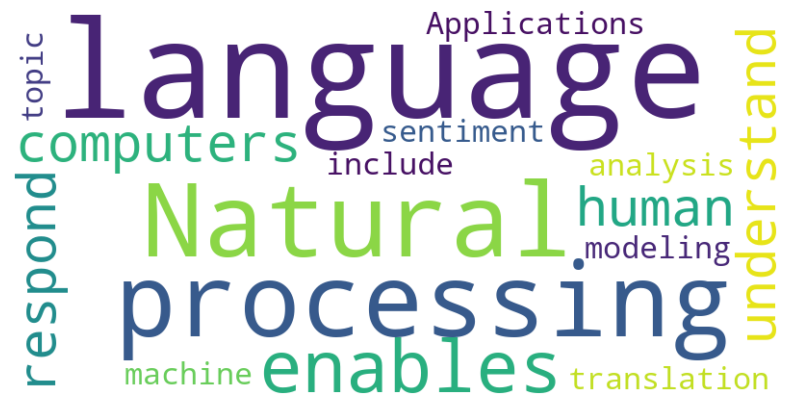

In [6]:
from wordcloud import WordCloud, STOPWORDS
import matplotlib.pyplot as plt

text = """
Natural language processing enables computers to understand and respond to human language.
Applications include sentiment analysis, machine translation, and topic modeling.
"""

# Create WordCloud
wc = WordCloud(
    width=800,
    height=400,
    background_color='white',
    stopwords=STOPWORDS
).generate(text)

# Display WordCloud
plt.figure(figsize=(10, 5))
plt.imshow(wc, interpolation='bilinear')
plt.axis("off")
plt.show()